In [ ]:
import os
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import yaml
from models.afe_linearity_characterization import (
    compute_inl,
    evaluate_dc_operating_point,
    extract_waveform_metrics,
    fit_gain,
)
from PyLTSpice import RawRead  # type: ignore

%config InlineBackend.figure_format = 'svg'

In [8]:
# ============================================
# Load Configuration
# ============================================
with open("config.yaml", "r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

# ============================================
# Output Directory Setup
# ============================================

REPORT_DIR = Path(config["paths"]["report_directory"])
REPORT_DIR.mkdir(exist_ok=True)

print(f"Reports directory ready at: {os.path.abspath(REPORT_DIR)}")

Reports directory ready at: /workspace/05_Verification/ElectronicHardware/Simulation/Analog/ANA-002_PulseLinearity/04_Report



========== ANA-002 Pulse Linearity ==========

--- DC Operating Point ---
Mean differential baseline: -33.641 mV
Mean common-mode voltage:   2.5006 V

--- Sweep Coverage ---
Minimum differential peak: 0.020604 V
Maximum differential peak: 1.553772 V
Required range: 0 to 1.000000 V peak

--- Linearity (INL) ---
Max INL: 0.0303 percent FS
Limit:   0.1000 percent FS
Linearity result: PASS


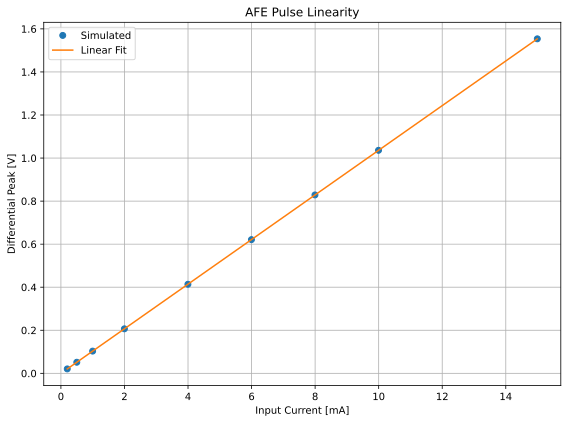

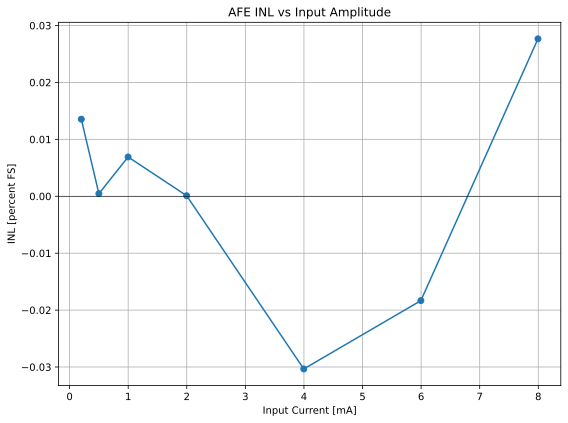


========== FINAL RESULT ==========
ANA-002: PASS



In [ ]:
# ============================================================
# Configuration
# ============================================================

config: Dict = config

ADC_BITS: int = int(config["adc"]["resolution"])
FULL_SCALE_VOLTAGE: float = float(config["adc"]["full_scale_voltage"])
ADC_LSB: float = FULL_SCALE_VOLTAGE / (2**ADC_BITS)

VREF: float = float(config["v_ref"]["voltage"])

# INL_LIMIT_PERCENT:
#   Requirement limit defined by ANA-002.
#   The maximum allowed integral non-linearity expressed
#   as percent of full-scale peak amplitude.
#
#   Requirement statement:
#       INL <= 0.1 percent of full-scale.
#
#   This is a hardware performance requirement.
#   Exceeding this value constitutes requirement failure.
INL_LIMIT_PERCENT: float = float(config["verification"]["ana_002"]["inl_limit_percent"])

# ZERO_COVERAGE_TOL_PERCENT:
#   Verification tolerance defining how close the minimum
#   measured differential peak must be to 0 V in order to
#   consider the sweep covering the lower bound of full-scale.
#
#   This is NOT a hardware requirement.
#   It prevents false failures caused by small DC offsets
#   or numerical residuals.
ZERO_COVERAGE_TOL_PERCENT: float = float(
    config["verification"]["ana_002"]["zero_coverage_tolerance_percent"]
)

# FS_COVERAGE_TOL_PERCENT:
#   Verification tolerance defining how close the maximum
#   measured differential peak must be to full-scale peak
#   amplitude in order to consider the sweep covering
#   the upper bound of full-scale.
#
#   This is NOT a hardware requirement.
#   It ensures the input sweep exercises the full dynamic range.
FS_COVERAGE_TOL_PERCENT: float = float(
    config["verification"]["ana_002"]["full_scale_coverage_tolerance_percent"]
)

# ============================================================
# Load RAW File
# ============================================================

raw_path: str = config["simulation"]["raw_file"]
raw: RawRead = RawRead(raw_path)

(
    input_amplitudes,
    output_peaks,
    output_baselines,
    output_common_mode,
) = extract_waveform_metrics(raw, config)

input_amplitudes = np.asarray(input_amplitudes)
output_peaks = np.asarray(output_peaks)
output_baselines = np.asarray(output_baselines)
output_common_mode = np.asarray(output_common_mode)

num_steps: int = len(input_amplitudes)

# ============================================================
# 0. DC Operating Point Verification
# ============================================================

dc: Dict[str, float] = evaluate_dc_operating_point(
    output_baselines,
    output_common_mode,
    FULL_SCALE_VOLTAGE,
    VREF,
)

print("\n========== ANA-002 Pulse Linearity ==========\n")
print("--- DC Operating Point ---")
print(f"Mean differential baseline: {dc['mean_diff']*1e3:.3f} mV")
print(f"Mean common-mode voltage:   {dc['mean_cm']:.4f} V")

dc_check: bool = bool(dc["dc_check"])

if not dc_check:
    raise RuntimeError("AFE not properly biased. Linearity evaluation invalid.")

# ============================================================
# 1. Sweep Coverage Validation (0 to FS)
# ============================================================

FS_peak: float = FULL_SCALE_VOLTAGE / 2.0

min_output: float = float(np.min(output_peaks))
max_output: float = float(np.max(output_peaks))

zero_tolerance: float = (ZERO_COVERAGE_TOL_PERCENT / 100.0) * FS_peak

fs_tolerance: float = (FS_COVERAGE_TOL_PERCENT / 100.0) * FS_peak

zero_covered: bool = min_output <= zero_tolerance
fs_covered: bool = max_output >= (FS_peak - fs_tolerance)

print("\n--- Sweep Coverage ---")
print(f"Minimum differential peak: {min_output:.6f} V")
print(f"Maximum differential peak: {max_output:.6f} V")
print(f"Required range: 0 to {FS_peak:.6f} V peak")

sweep_check: bool = zero_covered and fs_covered

if not sweep_check:
    raise RuntimeError("Input sweep does not cover full 0 to FS range.")

# ============================================================
# 2. Gain Fit and INL Calculation
# ============================================================

gain_measured: float
fit_line: np.ndarray
linear_region: np.ndarray

gain_measured, fit_line, linear_region = fit_gain(
    input_amplitudes,
    output_peaks,
    FULL_SCALE_VOLTAGE,
)

if not np.any(linear_region):
    raise RuntimeError("No valid linear region points for INL evaluation.")

(
    inl_volts,
    inl_percent,
    inl_lsb,
    max_inl_volts,
    max_inl_percent,
    max_inl_lsb,
) = compute_inl(
    output_peaks,
    fit_line,
    linear_region,
    FULL_SCALE_VOLTAGE,
    ADC_LSB,
)

print("\n--- Linearity (INL) ---")
print(f"Max INL: {max_inl_percent:.4f} percent FS")
print(f"Limit:   {INL_LIMIT_PERCENT:.4f} percent FS")

inl_check: bool = max_inl_percent <= INL_LIMIT_PERCENT

print(f"Linearity result: {'PASS' if inl_check else 'FAIL'}")

# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(8, 6))
plt.plot(input_amplitudes * 1e3, output_peaks, "o", label="Simulated")
plt.plot(input_amplitudes * 1e3, fit_line, "-", label="Linear Fit")
plt.xlabel("Input Current [mA]")
plt.ylabel("Differential Peak [V]")
plt.title("AFE Pulse Linearity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        REPORT_DIR,
        "ANA002_PulseLinearity_OutputVsInput.svg",
    )
)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(
    input_amplitudes[linear_region] * 1e3,
    inl_percent[linear_region],
    "o-",
)
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Input Current [mA]")
plt.ylabel("INL [percent FS]")
plt.title("AFE INL vs Input Amplitude")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(
        REPORT_DIR,
        "ANA002_PulseLinearity_INLPercentFS.svg",
    )
)
plt.show()

# ============================================================
# Final Result
# ============================================================

overall_pass: bool = dc_check and sweep_check and inl_check

print("\n========== FINAL RESULT ==========")
print(f"ANA-002: {'PASS' if overall_pass else 'FAIL'}")
print("==================================\n")